<a href="https://colab.research.google.com/github/meenub255/NXP_SEM_DEFECT/blob/main/hackathon_test_dataset_prediction_203_TENSOR_TITANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Testing ONNX model on the Hackathon Test dataset

In [ ]:
!pip install onnxruntime numpy pandas pillow tqdm scikit-learn seaborn matplotlib

In [ ]:
import os
import zipfile

zip_file_path = '/content/model_pack.zip'
extract_dir = '/content/unzipped_model_pack'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped successfully to '{extract_dir}'")
print("Contents of the unzipped directory:")
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

'/content/model_pack.zip' unzipped successfully to '/content/unzipped_model_pack'
Contents of the unzipped directory:
unzipped_model_pack/
    leaf_model_rt1170.onnx.data
    model_config.json
    leaf_model_rt1170.onnx


🚀 Loading Model and Scanning Data...
   - Found 30 images in 'CMP' (Label: CMP)
   - Found 30 images in 'LER' (Label: LER)
   - Found 32 images in 'Bridge' (Label: bridge)
   - Found 33 images in 'Clean' (Label: clean)
   - Found 31 images in 'Crack' (Label: cracks)
   - Found 30 images in 'Open' (Label: opens)
   - Found 30 images in 'VIA' (Label: vias)
   - Found 50 images in 'Other' (Label: others)
   - Found 30 images in 'Particle' (Label: others)

🧠 Running Inference on 296 images...


100%|██████████| 296/296 [00:03<00:00, 80.62it/s] 



📊 FINAL METRICS
✅ Accuracy:  25.68%
🎯 Precision: 36.15%
🔍 Recall:    25.68%
⚖️ F1 Score:  23.22%

--- Detailed Class Report ---
              precision    recall  f1-score   support

         CMP       0.18      0.83      0.29        30
         LER       0.00      0.00      0.00        30
      bridge       0.36      0.44      0.39        32
       clean       0.16      0.27      0.20        33
      cracks       0.57      0.26      0.36        31
       opens       0.33      0.03      0.06        30
        vias       0.33      0.20      0.25        30
      others       0.59      0.16      0.25        80

    accuracy                           0.26       296
   macro avg       0.32      0.27      0.23       296
weighted avg       0.36      0.26      0.23       296



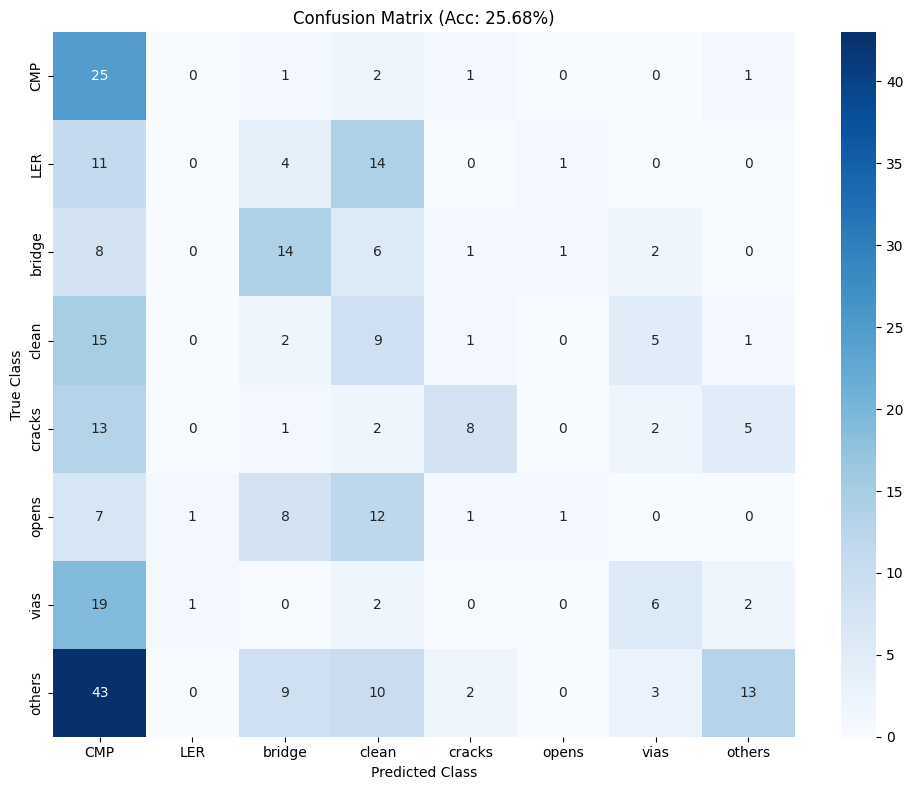

In [ ]:
import onnxruntime as ort
import numpy as np
import os
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# --- CONFIGURATION ---
MODEL_PATH = "/content/unzipped_model_pack/leaf_model_rt1170.onnx"
TEST_DATA_DIR = "/content/drive/MyDrive/SEM_IMAGES/hackathon_test_dataset"

# 1. Classes the Model knows (Output Indices 0-7)
INDEX_TO_CLASS = {
    0: "CMP",
    1: "LER",
    2: "bridge",
    3: "clean",    # Renamed from 'clean sem images' for clarity
    4: "cracks",
    5: "opens",
    6: "vias",
    7: "others"    # Renamed from 'voids' to represent the catch-all class
}

# 2. Map Hackathon Folders to Model Classes
FOLDER_TO_CLASS = {
    "CMP": "CMP",
    "LER": "LER",
    "Bridge": "bridge",
    "Clean": "clean",
    "Crack": "cracks",
    "Open": "opens",
    "VIA": "vias",
    "Other": "others",    # Mapped to 'others'
    "Particle": "others"  # Mapped to 'others'
}

# Order for Confusion Matrix
EVALUATION_CLASSES = ["CMP", "LER", "bridge", "clean", "cracks", "opens", "vias", "others"]

def preprocess_image(image_path, target_size=(224, 224)):
    try:
        image = Image.open(image_path).convert('RGB')
        image = image.resize(target_size, resample=Image.BILINEAR)
        img_data = np.array(image).astype('float32') / 255.0

        # ImageNet Normalization
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_data = (img_data - mean) / std

        # Transpose to (1, C, H, W)
        img_data = np.transpose(img_data, (2, 0, 1))
        img_data = np.expand_dims(img_data, axis=0)
        return img_data.astype(np.float32)
    except Exception as e:
        return None

def main():
    # --- 1. SETUP & DATA LOADING ---
    if not os.path.exists(MODEL_PATH):
        print(f"❌ Error: Model not found at {MODEL_PATH}")
        return

    print("🚀 Loading Model and Scanning Data...")
    session = ort.InferenceSession(MODEL_PATH)
    input_name = session.get_inputs()[0].name

    image_paths = []
    y_true = []

    # Scan folders based on our mapping
    for folder_name, class_label in FOLDER_TO_CLASS.items():
        folder_path = os.path.join(TEST_DATA_DIR, folder_name)
        if os.path.exists(folder_path):
            files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for f in files:
                image_paths.append(os.path.join(folder_path, f))
                y_true.append(class_label)
            print(f"   - Found {len(files)} images in '{folder_name}' (Label: {class_label})")

    if not image_paths:
        print("❌ No images found!")
        return

    # --- 2. INFERENCE ---
    print(f"\n🧠 Running Inference on {len(image_paths)} images...")
    y_pred = []

    for img_path in tqdm(image_paths):
        data = preprocess_image(img_path)
        if data is not None:
            outputs = session.run(None, {input_name: data})
            pred_idx = np.argmax(outputs[0])
            y_pred.append(INDEX_TO_CLASS[pred_idx])
        else:
            y_pred.append("ERROR")

    # Clean up any errors
    valid_indices = [i for i, p in enumerate(y_pred) if p != "ERROR"]
    y_true = [y_true[i] for i in valid_indices]
    y_pred = [y_pred[i] for i in valid_indices]

    # --- 3. METRICS CALCULATION (ACCURACY, PRECISION, RECALL) ---
    print("\n" + "="*40)
    print("📊 FINAL METRICS")
    print("="*40)

    # A. Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"✅ Accuracy:  {acc * 100:.2f}%")

    # B. Precision (Weighted Average)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"🎯 Precision: {prec * 100:.2f}%")

    # C. Recall (Weighted Average)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"🔍 Recall:    {rec * 100:.2f}%")

    # D. F1 Score (Weighted Average)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"⚖️ F1 Score:  {f1 * 100:.2f}%")

    # --- 4. DETAILED REPORT & CONFUSION MATRIX ---
    print("\n--- Detailed Class Report ---")
    print(classification_report(y_true, y_pred, labels=EVALUATION_CLASSES, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=EVALUATION_CLASSES)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EVALUATION_CLASSES, yticklabels=EVALUATION_CLASSES)
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.title(f'Confusion Matrix (Acc: {acc*100:.2f}%)')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

#Generation of LOG FILE

In [ ]:
import onnxruntime as ort
import numpy as np
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from datetime import datetime

# --- CONFIGURATION ---
MODEL_PATH = "/content/unzipped_model_pack/leaf_model_rt1170.onnx"
TEST_DATA_DIR = "/content/drive/MyDrive/SEM_IMAGES/hackathon_test_dataset"
CSV_LOG_FILE = "prediction_run_log.csv"  # <--- The file you requested

# --- MAPPINGS ---
# 1. Map Model Output Indices to Class Names
# Note: We rename 'voids' to 'others' for the final report
INDEX_TO_CLASS = {
    0: "CMP",
    1: "LER",
    2: "bridge",
    3: "clean",
    4: "cracks",
    5: "opens",
    6: "vias",
    7: "others"
}

# 2. Map Hackathon Folders to Class Names
FOLDER_TO_CLASS = {
    "CMP": "CMP",
    "LER": "LER",
    "Bridge": "bridge",
    "Clean": "clean",
    "Crack": "cracks",
    "Open": "opens",
    "VIA": "vias",
    "Other": "others",
    "Particle": "others"
}

EVALUATION_CLASSES = ["CMP", "LER", "bridge", "clean", "cracks", "opens", "vias", "others"]

def preprocess_image(image_path, target_size=(224, 224)):
    try:
        image = Image.open(image_path).convert('RGB')
        image = image.resize(target_size, resample=Image.BILINEAR)
        img_data = np.array(image).astype('float32') / 255.0

        # ImageNet Normalization
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_data = (img_data - mean) / std

        img_data = np.transpose(img_data, (2, 0, 1))
        img_data = np.expand_dims(img_data, axis=0)
        return img_data.astype(np.float32)
    except Exception as e:
        return None

def softmax(x):
    """Compute softmax values for each set of scores in x."""
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

def main():
    print(f"--- STARTING PREDICTION RUN: {datetime.now()} ---")

    if not os.path.exists(MODEL_PATH):
        print(f"❌ Model not found at {MODEL_PATH}")
        return

    # Load Model
    session = ort.InferenceSession(MODEL_PATH)
    input_name = session.get_inputs()[0].name
    print(f"✅ Model loaded successfully")

    # Prepare Data
    image_paths = []
    y_true_list = []

    print("📂 Scanning dataset folders...")
    for folder_name, class_label in FOLDER_TO_CLASS.items():
        folder_path = os.path.join(TEST_DATA_DIR, folder_name)
        if os.path.exists(folder_path):
            files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for f in files:
                image_paths.append(os.path.join(folder_path, f))
                y_true_list.append(class_label)
            print(f"   - {folder_name}: {len(files)} images (Mapped to '{class_label}')")

    if not image_paths:
        print("❌ No images found.")
        return

    # --- RUN INFERENCE & GENERATE LOG ---
    print(f"\n🧠 Running inference on {len(image_paths)} images...")

    log_data = [] # This list will hold the CSV rows
    y_pred_list = []

    for i, img_path in enumerate(tqdm(image_paths)):
        data = preprocess_image(img_path)
        true_label = y_true_list[i]
        filename = os.path.basename(img_path)

        if data is not None:
            # Inference
            outputs = session.run(None, {input_name: data})
            logits = outputs[0][0]

            # Prediction
            pred_idx = np.argmax(logits)
            pred_label = INDEX_TO_CLASS[pred_idx]

            # Confidence
            probs = softmax(logits)
            confidence = probs[pred_idx]

            y_pred_list.append(pred_label)

            # APPEND TO LOG DATA
            log_data.append({
                "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "Filename": filename,
                "True_Class_Folder": os.path.basename(os.path.dirname(img_path)),
                "Mapped_True_Class": true_label,
                "Predicted_Class": pred_label,
                "Confidence": f"{confidence:.4f}",
                "Outcome": "Correct" if true_label == pred_label else "Incorrect"
            })
        else:
            y_pred_list.append("ERROR")
            log_data.append({
                "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "Filename": filename,
                "Outcome": "Error Loading Image"
            })

    # --- SAVE THE CSV LOG FILE ---
    df_log = pd.DataFrame(log_data)
    df_log.to_csv(CSV_LOG_FILE, index=False)
    print(f"\n✅ PREDICTION LOG SAVED TO: {CSV_LOG_FILE}")
    print(f"   (You can download this file to view the full run details)")


if __name__ == "__main__":
    main()

--- STARTING PREDICTION RUN: 2026-02-16 14:20:48.248176 ---
✅ Model loaded successfully
📂 Scanning dataset folders...
   - CMP: 30 images (Mapped to 'CMP')
   - LER: 30 images (Mapped to 'LER')
   - Bridge: 32 images (Mapped to 'bridge')
   - Clean: 33 images (Mapped to 'clean')
   - Crack: 31 images (Mapped to 'cracks')
   - Open: 30 images (Mapped to 'opens')
   - VIA: 30 images (Mapped to 'vias')
   - Other: 50 images (Mapped to 'others')
   - Particle: 30 images (Mapped to 'others')

🧠 Running inference on 296 images...


100%|██████████| 296/296 [00:04<00:00, 68.04it/s] 


✅ PREDICTION LOG SAVED TO: prediction_run_log.csv
   (You can download this file to view the full run details)
